In [69]:
import pandas as pd
import numpy as np
from scipy.stats import kstest, shapiro, norm
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pingouin as pg


In [2]:
overview_df = pd.read_parquet("./output/overview.parquet")

In [4]:
overview_df

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, 0, 0, -1, -...","{'lint_level': [0, 0, -1, 0, -1, -1, 0, -1, -1...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."
roleplay,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 2, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, 0, -1, -1, -1, -1, 0, -1, ...","{'lint_level': [0, 0, 0, 0, -1, 0, 0, -1, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, -1, -1, -1, 0, -1,..."
meta,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 2, ...","{'lint_level': [2, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-1, 0, -1, 0, -1, -1, 0, -1, -...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-2, -1, -1, 0, -1, -2, 0, -1, ..."
cot,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 2, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 2, 2, 1, 2, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, 0, 0, -1, -1, 0, -1, -...","{'lint_level': [0, 0, 0, 0, -1, -1, 1, -1, 0, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."


In [3]:
zkb = pd.concat(
    {col: pd.json_normalize(overview_df[col]) for col in overview_df.columns},
    axis=1
)

zkb = zkb.apply(lambda x: x.map(np.array))
zkb

Org  \
                                                 lint_level   
standard  [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
roleplay  [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
meta      [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   
cot       [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 2, 3, 3, 3, 2, ...   

                                                             \
                                                 lint_score   
standard  [51.787887017911295, 44.27195203809244, 42.014...   
roleplay  [51.787887017911295, 44.27195203809244, 42.014...   
meta      [51.787887017911295, 44.27195203809244, 42.014...   
cot       [51.787887017911295, 44.27195203809244, 42.014...   

                                                             \
                                             max_lint_score   
standard  [88.01970614660702, 80.87266839991977, 78.3902...   
roleplay  [88.01970614660702, 80.87266839991977, 78.3902...   
meta      [88.01970614660702, 80.87266839991977, 78.3902...   
cot       [88.01970614660702, 80.87266839991977, 78.3902...   

                                                             \
                              mean_content_words_per_clause   
standard  [5.150793650793651, 4.825757575757576, 4.27586...   
roleplay  [5.150793650793651, 4.825757575757576, 4.27586...   
meta      [5.150793650793651, 4.825757575757576, 4.27586...   
cot       [5.150793650793651, 4.825757575757576, 4.27586...   

                                                             \
                                    mean_log_word_frequency   
standard  [4.2194244570113115, 4.487244917555749, 4.4093...   
roleplay  [4.2194244570113115, 4.487244917555749, 4.4093...   
meta      [4.2194244570113115, 4.487244917555749, 4.4093...   
cot       [4.2194244570113115, 4.487244917555749, 4.4093...   

                                                             \
                                               mean_max_sdl   
standard  [6.782608695652174, 7.090909090909091, 7.06666...   
roleplay  [6.782608695652174, 7.090909090909091, 7.06666...   
meta      [6.782608695652174, 7.090909090909091, 7.06666...   
cot       [6.782608695652174, 7.090909090909091, 7.06666...   

                                                             \
                                           mean_sent_length   
standard  [13.434782608695652, 15.272727272727273, 13.73...   
roleplay  [13.434782608695652, 15.272727272727273, 13.73...   
meta      [13.434782608695652, 15.272727272727273, 13.73...   
cot       [13.434782608695652, 15.272727272727273, 13.73...   

                                                             \
                                             min_lint_score   
standard  [25.91116226849178, 12.16223138953248, 16.0646...   
roleplay  [25.91116226849178, 12.16223138953248, 16.0646...   
meta      [25.91116226849178, 12.16223138953248, 16.0646...   
cot       [25.91116226849178, 12.16223138953248, 16.0646...   

                                                             \
                               proportion_of_concrete_nouns   
standard  [0.2235294117647059, 0.38372093023255816, 0.51...   
roleplay  [0.2235294117647059, 0.38372093023255816, 0.51...   
meta      [0.2235294117647059, 0.38372093023255816, 0.51...   
cot       [0.2235294117647059, 0.38372093023255816, 0.51...   

                                                             ...  \
                                               text_is_easy  ...   
standard  [True, True, True, False, False, True, True, F...  ...   
roleplay  [True, True, True, False, False, True, True, F...  ...   
meta      [True, True, True, False, False, True, True, F...  ...   
cot       [True, True, True, False, False, True, True, F...  ...   

                        Mistral/ministral-14b-latest - diff  \
                                                 lint_score   
standard  [-12.452174166631742, -14.970689561995542, -9....   
roleplay  [-15.461479726164356, -13.43014544338

In [5]:
# Calculate max value for standard
lintlvl = zkb.xs("lint_score", 1, 1)
lintlvl

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[47.270436794584576, 34.97574630454368, 32.145...","[31.295976806883857, 23.178400584253467, 24.89...","[39.33571285127955, 29.301262476096895, 32.103...","[-10.837340387071144, -11.717945105265855, -8....","[-4.517450223326719, -9.29620573354876, -9.869...","[-20.491910211027438, -21.09355145383897, -17....","[-12.452174166631742, -14.970689561995542, -9...."
roleplay,"[51.787887017911295, 44.27195203809244, 42.014...","[42.8369755216941, 36.930944892351974, 29.9036...","[47.47706931933917, 40.90997001137065, 34.0834...","[31.23516639301363, 17.10840202445779, 24.5797...","[36.32640729174694, 30.841806594710974, 32.783...","[-8.950911496217195, -7.341007145740463, -12.1...","[-4.310817698572123, -3.3619820267217833, -7.9...","[-20.552720624897667, -27.163550013634648, -17...","[-15.461479726164356, -13.430145443381463, -9...."
meta,"[51.787887017911295, 44.27195203809244, 42.014...","[42.42687699847713, 31.30478922763149, 27.9868...","[44.043455385890624, 34.64707155635908, 31.642...","[24.157303152570066, 16.94794909806963, 22.026...","[28.909354967801818, 24.161288643111334, 33.54...","[-9.361010019434168, -12.967162810460948, -14....","[-7.744431632020671, -9.624880481733356, -10.3...","[-27.63058386534123, -27.324002940022808, -19....","[-22.878532050109477, -20.110663394981103, -8...."
cot,"[51.787887017911295, 44.27195203809244, 42.014...","[43.96274912152043, 33.53410962266683, 35.7956...","[47.42365613314291, 35.76820859382585, 36.9622...","[25.389145339701898, 22.696289618998392, 27.96...","[39.934580252798895, 30.00757458291966, 28.974...","[-7.8251378963908635, -10.737842415425604, -6....","[-4.364230884768382, -8.50374344426659, -5.052...","[-26.398741678209397, -21.575662419094044, -14...","[-11.8533067651124, -14.264377455172777, -13.0..."


In [6]:
lintlvl.iloc[:,0:5]

max_val = 0
for idx, row in lintlvl.iloc[:,0:5].iterrows():
    vls = np.array([r for r in row.values]) # Somehow, flattening the array using .flatten() doesn't work, but this does.
    temp_max = np.max(vls)
    if temp_max > max_val:
        max_val = temp_max
print("MAX", max_val)

MAX 68.48813079213978


In [7]:
dummy_models = []
all_gains = []
all_gains_v2 = []
postpre = []
for idx, row in lintlvl.iloc[:,0:5].iterrows():
    print("=====", idx)
    org_vls = row.values[0]
    vls = np.array([r for r in row.values[1:]]) # Somehow, flattening the array using .flatten() doesn't work, but this does.
    # print(vls)
    # print(vls)
    avg_model_score_per_text = np.mean(vls, axis = 0)
    post_min_pre = avg_model_score_per_text - org_vls
    max_min_pre = max_val - org_vls
    gain = post_min_pre / max_min_pre
    gain_v2 = post_min_pre / org_vls
    # NORMALIZED GAIN: https://www.physport.org/recommendations/Entry.cfm?ID=93334
    # print("org lint score")
    # print(org_vls[-7])
    # print("average lint score model")
    # print(avg_model_score_per_text[-7])
    # print("post - pre")
    # print(post_min_pre[-7])
    # print(f"max {max_val} - pre")
    # print(max_min_pre[-7])
    # print("gain")
    # print(np.min(gain), np.max(gain))
    dummy_models.append(avg_model_score_per_text)
    all_gains.append(gain)
    all_gains_v2.append(gain_v2)
    postpre.append(post_min_pre)

===== standard
===== roleplay
===== meta
===== cot


In [8]:
lintlvl['dummy_model'] = dummy_models
lintlvl['post-min-pre'] = postpre
lintlvl['norm.gain'] = all_gains
lintlvl['norm.gain.v2'] = all_gains_v2

In [9]:
lintlvl

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff,dummy_model,post-min-pre,norm.gain,norm.gain.v2
standard,"[51.787887017911295, 44.27195203809244, 42.014...","[40.95054663084015, 32.55400693282658, 33.7822...","[47.270436794584576, 34.97574630454368, 32.145...","[31.295976806883857, 23.178400584253467, 24.89...","[39.33571285127955, 29.301262476096895, 32.103...","[-10.837340387071144, -11.717945105265855, -8....","[-4.517450223326719, -9.29620573354876, -9.869...","[-20.491910211027438, -21.09355145383897, -17....","[-12.452174166631742, -14.970689561995542, -9....","[39.71316827089703, 30.002354074430155, 30.730...","[-12.074718747014266, -14.269597963662282, -11...","[-0.7230264965142456, -0.5892588632001796, -0....","[-0.23315720030898573, -0.3223168915475976, -0..."
roleplay,"[51.787887017911295, 44.27195203809244, 42.014...","[42.8369755216941, 36.930944892351974, 29.9036...","[47.47706931933917, 40.90997001137065, 34.0834...","[31.23516639301363, 17.10840202445779, 24.5797...","[36.32640729174694, 30.841806594710974, 32.783...","[-8.950911496217195, -7.341007145740463, -12.1...","[-4.310817698572123, -3.3619820267217833, -7.9...","[-20.552720624897667, -27.163550013634648, -17...","[-15.461479726164356, -13.430145443381463, -9....","[39.46890463144846, 31.447780880722846, 30.337...","[-12.318982386462835, -12.824171157369591, -11...","[-0.7376528482460396, -0.5295703871208927, -0....","[-0.23787381752420614, -0.289668075768049, -0...."
meta,"[51.787887017911295, 44.27195203809244, 42.014...","[42.42687699847713, 31.30478922763149, 27.9868...","[44.043455385890624, 34.64707155635908, 31.642...","[24.157303152570066, 16.94794909806963, 22.026...","[28.909354967801818, 24.161288643111334, 33.54...","[-9.361010019434168, -12.967162810460948, -14....","[-7.744431632020671, -9.624880481733356, -10.3...","[-27.63058386534123, -27.324002940022808, -19....","[-22.878532050109477, -20.110663394981103, -8....","[34.88424762618491, 26.765274631292883, 28.800...","[-16.903639391726387, -17.506677406799554, -13...","[-1.0121792005103407, -0.7229331094970379, -0....","[-0.32640141092993646, -0.39543495601315415, -..."
cot,"[51.787887017911295, 44.27195203809244, 42.014...","[43.96274912152043, 33.53410962266683, 35.7956...","[47.42365613314291, 35.76820859382585, 36.9622...","[25.389145339701898, 22.696289618998392, 27.96...","[39.934580252798895, 30.00757458291966, 28.974...","[-7.8251378963908635, -10.737842415425604, -6....","[-4.364230884768382, -8.50374344426659, -5.052...","[-26.398741678209397, -21.575662419094044, -14...","[-11.8533067651124, -14.264377455172777, -13.0...","[39.17753271179103, 30.501545604602683, 32.423...","[-12.610354306120264, -13.770406433489754, -9....","[-0.7551000139040085, -0.5686448953548565, -0....","[-0.2435000737094924, -0.31104132073601437, -0..."


In [10]:
np.std(lintlvl.iloc[0, 12]), np.mean(lintlvl.iloc[0, -5])

(0.08420518500357692, -10.463846362992808)

In [13]:
print(shapiro(lintlvl.iloc[0, -4]))
print(shapiro(lintlvl.iloc[1, -4]))
print(shapiro(lintlvl.iloc[2, -4]))
print(shapiro(lintlvl.iloc[3, -4]))

ShapiroResult(statistic=0.9739936170427321, pvalue=0.4768502128009089)
ShapiroResult(statistic=0.9503674942023665, pvalue=0.07807120338773645)
ShapiroResult(statistic=0.9770477455019898, pvalue=0.581150604231876)
ShapiroResult(statistic=0.9757019301207441, pvalue=0.5338397112498827)


In [12]:
print(kstest(lintlvl.iloc[0, -4], norm.cdf))
print(kstest(lintlvl.iloc[1, -4], 'norm'))
print(kstest(lintlvl.iloc[2, -4], 'norm'))
print(kstest(lintlvl.iloc[3, -4], 'norm'))

KstestResult(statistic=1.0, pvalue=0.0, statistic_location=23.665401657024255, statistic_sign=-1)
KstestResult(statistic=1.0, pvalue=0.0, statistic_location=24.08680456590827, statistic_sign=-1)
KstestResult(statistic=1.0, pvalue=0.0, statistic_location=23.61387878326096, statistic_sign=-1)
KstestResult(statistic=1.0, pvalue=0.0, statistic_location=25.849533075134655, statistic_sign=-1)


In [ ]:
AnovaRM(data=df, depvar='response', subject='patient', within=['drug']).fit()

In [16]:
lintlvl.iloc[0, -4]

array([39.71316827, 30.00235407, 30.7309502 , 33.53164206, 25.07754145,
       39.2623574 , 30.30453986, 28.59347177, 26.84360814, 29.03390165,
       29.10762233, 38.4235734 , 40.69965327, 38.68022658, 25.4712552 ,
       23.66540166, 27.0770798 , 36.77569889, 26.93674759, 29.5660071 ,
       31.72338639, 32.59966722, 28.3354305 , 35.46948082, 31.1516542 ,
       33.05040481, 26.41011674, 33.32438479, 29.35950322, 29.66256383,
       38.65473696, 41.25342974, 34.60718606, 44.11237585, 34.35156659,
       36.46428272, 38.66659597, 32.17467445, 32.68377309, 35.03676417])

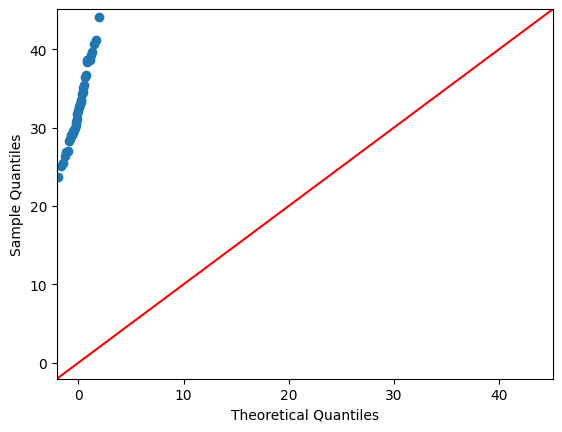

In [18]:
fig = sm.qqplot(lintlvl.iloc[0, -4], line='45')
plt.show()

In [22]:
overview_df

,Org,ChatGPT 4.1 mini/gpt-4.1-mini,GPT 5.1 mini/gpt-5-mini,Gemini/gemini-3-flash-preview,Mistral/ministral-14b-latest,ChatGPT 4.1 mini/gpt-4.1-mini - diff,GPT 5.1 mini/gpt-5-mini - diff,Gemini/gemini-3-flash-preview - diff,Mistral/ministral-14b-latest - diff
standard,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, 0, 0, -1, -...","{'lint_level': [0, 0, -1, 0, -1, -1, 0, -1, -1...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."
roleplay,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 2, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 3, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 1, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, 0, -1, -1, -1, -1, 0, -1, ...","{'lint_level': [0, 0, 0, 0, -1, 0, 0, -1, -1, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, -1, -1, -1, 0, -1,..."
meta,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 2, ...","{'lint_level': [2, 2, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [1, 1, 1, 2, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ...","{'lint_level': [-1, 0, -1, 0, -1, -1, 0, -1, -...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-2, -1, -1, 0, -1, -2, 0, -1, ..."
cot,"{'lint_level': [3, 2, 2, 2, 2, 3, 1, 2, 2, 2, ...","{'lint_level': [2, 1, 2, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [3, 2, 2, 2, 1, 2, 2, 1, 2, 1, ...","{'lint_level': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","{'lint_level': [2, 1, 1, 2, 1, 2, 1, 1, 1, 1, ...","{'lint_level': [-1, -1, 0, 0, -1, -1, 0, -1, -...","{'lint_level': [0, 0, 0, 0, -1, -1, 1, -1, 0, ...","{'lint_level': [-2, -1, -1, -1, -1, -2, 0, -1,...","{'lint_level': [-1, -1, -1, 0, -1, -1, 0, -1, ..."


In [52]:
records = []

columns = list(lintlvl.columns.values)
print(columns)
for models in lintlvl.itertuples():
    # print(prompt)
    print(len(models))
    print(models.Index)
    # print(models._2)
    # print(models)
    # print(models.column)
    # print(type(models), len(models))
    prompt_type = models.Index
    for index, lint_score in enumerate(models[1:]):
        # print(model)
        print("lengte", len(lint_score))
        print(index, lint_score)
        
        for text, ls in enumerate(lint_score):
            print("tekst", text, "lint score", ls)
            records.append(
                {
                    "tekst": text,
                    "prompt_type": prompt_type,
                    "model": columns[index],
                    "score": ls
                }
            )
    

['Org', 'ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest', 'ChatGPT 4.1 mini/gpt-4.1-mini - diff', 'GPT 5.1 mini/gpt-5-mini - diff', 'Gemini/gemini-3-flash-preview - diff', 'Mistral/ministral-14b-latest - diff', 'dummy_model', 'post-min-pre', 'norm.gain', 'norm.gain.v2']
14
standard
lengte 40
0 [51.78788702 44.27195204 42.01484679 41.73047398 36.41633826 53.45974778
 33.7884481  34.29964099 35.63811598 35.942526   36.04815709 49.57545814
 53.04274792 53.68063737 43.20998372 30.74022212 53.16578509 64.48584901
 31.28092504 40.35790065 42.27971024 45.10012882 38.47826859 44.228571
 45.40480214 40.7485339  32.08573087 44.95534597 32.82549627 33.79125201
 56.32801162 58.84585487 45.96075655 63.74358302 39.10405441 46.74079593
 50.22265812 47.5599297  52.42048877 49.62476538]
tekst 0 lint score 51.787887017911295
tekst 1 lint score 44.27195203809244
tekst 2 lint score 42.01484679202095
tekst 3 lint score 41.7304739796

In [53]:
records

[{'tekst': 0,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 51.787887017911295},
 {'tekst': 1,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 44.27195203809244},
 {'tekst': 2,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 42.01484679202095},
 {'tekst': 3,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 41.73047397969161},
 {'tekst': 4,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 36.416338260970214},
 {'tekst': 5,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 53.45974778002985},
 {'tekst': 6,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 33.788448096944194},
 {'tekst': 7,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 34.29964098773658},
 {'tekst': 8,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 35.638115979818764},
 {'tekst': 9,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 35.942525997382106},
 {'tekst': 10,
  'prompt_type': 'standard',
  'model': 'Org',
  'score': 36

In [55]:
long_df = pd.DataFrame(records)
long_df

,tekst,prompt_type,model,score
0,0,standard,Org,51.787887
1,1,standard,Org,44.271952
2,2,standard,Org,42.014847
3,3,standard,Org,41.730474
4,4,standard,Org,36.416338
...,...,...,...,...
2075,35,cot,norm.gain.v2,-0.265620
2076,36,cot,norm.gain.v2,-0.252800
2077,37,cot,norm.gain.v2,-0.323173
2078,38,cot,norm.gain.v2,-0.306888


In [56]:
long_df[long_df.model.isin(['ChatGPT 4.1 mini/gpt-4.1-mini', 'GPT 5.1 mini/gpt-5-mini', 'Gemini/gemini-3-flash-preview', 'Mistral/ministral-14b-latest'])] 

,tekst,prompt_type,model,score
40,0,standard,ChatGPT 4.1 mini/gpt-4.1-mini,40.950547
41,1,standard,ChatGPT 4.1 mini/gpt-4.1-mini,32.554007
42,2,standard,ChatGPT 4.1 mini/gpt-4.1-mini,33.782212
43,3,standard,ChatGPT 4.1 mini/gpt-4.1-mini,37.692759
44,4,standard,ChatGPT 4.1 mini/gpt-4.1-mini,29.102002
...,...,...,...,...
1755,35,cot,Mistral/ministral-14b-latest,32.143897
1756,36,cot,Mistral/ministral-14b-latest,38.214901
1757,37,cot,Mistral/ministral-14b-latest,29.917135
1758,38,cot,Mistral/ministral-14b-latest,33.587112


In [62]:
anova_check_df = long_df[long_df.model.isin(['dummy_model'])]
anova_check_df

,tekst,prompt_type,model,score
360,0,standard,dummy_model,39.713168
361,1,standard,dummy_model,30.002354
362,2,standard,dummy_model,30.730950
363,3,standard,dummy_model,33.531642
364,4,standard,dummy_model,25.077541
...,...,...,...,...
1955,35,cot,dummy_model,34.325487
1956,36,cot,dummy_model,37.526374
1957,37,cot,dummy_model,32.189839
1958,38,cot,dummy_model,36.333284


In [63]:
print(AnovaRM(data=anova_check_df, depvar='score', subject='tekst', within=['prompt_type']).fit())

                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
prompt_type  9.5074 3.0000 117.0000 0.0000



In [72]:
anova_check_df[anova_check_df.prompt_type == 'standard'].score

360    39.713168
361    30.002354
362    30.730950
363    33.531642
364    25.077541
365    39.262357
366    30.304540
367    28.593472
368    26.843608
369    29.033902
370    29.107622
371    38.423573
372    40.699653
373    38.680227
374    25.471255
375    23.665402
376    27.077080
377    36.775699
378    26.936748
379    29.566007
380    31.723386
381    32.599667
382    28.335430
383    35.469481
384    31.151654
385    33.050405
386    26.410117
387    33.324385
388    29.359503
389    29.662564
390    38.654737
391    41.253430
392    34.607186
393    44.112376
394    34.351567
395    36.464283
396    38.666596
397    32.174674
398    32.683773
399    35.036764
Name: score, dtype: float64

In [73]:
shapiro(anova_check_df[anova_check_df.prompt_type == 'standard'].score)

ShapiroResult(statistic=0.9739936170427321, pvalue=0.4768502128009089)

In [74]:
kstest(anova_check_df[anova_check_df.prompt_type == 'standard'].score, 'norm')

KstestResult(statistic=1.0, pvalue=0.0, statistic_location=23.665401657024255, statistic_sign=-1)

## Is normality assumption met?

In [70]:
pg.normality(data=anova_check_df, dv='score', group='prompt_type')

,W,pval,normal
prompt_type,,,
standard,0.973994,0.476850,True
roleplay,0.950367,0.078071,True
meta,0.977048,0.581151,True
cot,0.975702,0.533840,True


In [79]:
pg.sphericity(data=anova_check_df, dv='score', subject='tekst', within='prompt_type')

SpherResults(spher=False, W=0.2547250776958752, chi2=51.58779612155908, dof=5, pval=6.730544319983779e-10)

In [ ]:
# if sphericity = False, report the p_GG_corr p value (Greenhouse Geisser)
print(pg.rm_anova(data=anova_check_df, dv='score', subject='tekst', within='prompt_type', detailed=True, correction=True))

        Source          SS   DF         MS         F     p_unc  p_GG_corr  \
0  prompt_type  121.617358    3  40.539119  9.507374  0.000011   0.000475   
1        Error  498.883999  117   4.263966       NaN       NaN        NaN   

        ng2       eps sphericity   W_spher       p_spher  
0  0.035802  0.568344      False  0.254725  6.730544e-10  
1       NaN       NaN        NaN       NaN           NaN  


In [ ]:
# If p corrected value <0.05, then you can assume it is statistically significant. 

posthocs = pg.pairwise_tests(
    data=anova_check_df, dv='score', subject='tekst', within='prompt_type', padjust="bonf"
)
posthocs

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,prompt_type,cot,meta,True,True,4.105769,39.0,two-sided,0.000199,0.001196,bonf,129.988,0.565982
1,prompt_type,cot,roleplay,True,True,0.522078,39.0,two-sided,0.604569,1.000000,bonf,0.194,0.036523
2,prompt_type,cot,standard,True,True,1.908248,39.0,two-sided,0.063740,0.382440,bonf,0.881,0.136917
3,prompt_type,meta,roleplay,True,True,-3.212943,39.0,two-sided,0.002636,0.015814,bonf,12.957,-0.448714
4,prompt_type,meta,standard,True,True,-2.829181,39.0,two-sided,0.007335,0.044008,bonf,5.319,-0.359193
5,prompt_type,roleplay,standard,True,True,2.095658,39.0,two-sided,0.042653,0.255919,bonf,1.216,0.089148
